In [22]:
import re
import unicodedata
from pathlib import Path
import numpy as np
import pandas as pd


def clean_names(df: pd.DataFrame) -> pd.DataFrame:
    def _clean(s: str) -> str:
        # Quita acentos y normaliza texto
        s = (
            unicodedata.normalize("NFKD", s)
            .encode("ascii", "ignore")
            .decode("ascii")
        )
        s = s.strip().lower()
        s = re.sub(r"[^\w\s]", "_", s)  # reemplaza símbolos por _
        s = re.sub(r"\s+", "_", s)  # espacios -> _
        s = re.sub(r"_+", "_", s)  # colapsa múltiples _
        s = s.strip("_")
        return s

    df = df.copy()
    df.columns = [_clean(c) for c in df.columns]
    return df

base_dir = Path("./data")

universo = pd.read_csv(
    base_dir / "usuarios_propension.csv", dtype={"rpp_user_id": str}
)
universo = clean_names(universo)

notificaciones = pd.read_csv(
    base_dir / "aux_notificaciones.csv", dtype={"rpp_user_id": str}
)
notificaciones = clean_names(notificaciones)[["external_id", "disable_push"]]

ofertas = pd.read_csv(base_dir / "ofertas.csv", dtype={"rpp_user_id": str})
ofertas = clean_names(ofertas)

universo = universo.merge(ofertas, on="rpp_user_id", how="left").merge(
    notificaciones, on="external_id", how="left"
)

In [25]:
universo

,external_id,rpp_user_id,contract_number,treat,new_credit_line,gender,antiguedad_meses,wa_enviados_30,wa_leidos_30,wa_respuestas_30,...,prom_saldo_dispuesto_90d,prom_saldo_dispuesto_30d,prom_saldo_dispuesto_7d,last_purchase_90d,d_incremento,treat_label,num_ofertas_historicas,num_ofertas_aceptadas,num_ofertas_no_aceptadas,disable_push
0,634895718,c0ccf5ec-9521-4d18-a99e-1a6c7e451711,19000100000776503,0,5000,H,47,6,1,0,...,38713.161368,1039.025477,25593.233299,72,0,Control,5,3,2,1
1,299900595,2f8b36e8-c416-4511-975e-da288a83419e,19000100000191627,0,15000,M,26,14,8,3,...,3269.983856,45620.335096,28159.030556,89,0,Control,4,2,2,0
2,962061404,e0d5ae03-e5e7-4518-961e-dd7bc1380c90,19000100000222772,0,15000,H,52,5,14,2,...,14763.104228,34326.417561,27613.315778,34,0,Control,9,1,8,0
3,887846414,f16c4ac4-9c77-4157-865a-b8674a2ce787,19000100000329415,0,80000,H,47,3,5,1,...,4160.368814,47155.157907,37499.290531,32,0,Control,5,0,5,0
4,227521863,edf1d598-929a-416e-876f-4bdd283435d6,19000100000765582,0,50000,M,46,2,5,4,...,37053.345132,38481.086663,42061.867940,54,0,Control,5,2,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13997,921325165,1fc7eaf9-e124-4cdb-841a-40c5d2f9cb9f,19000100000990567,0,25000,M,2,1,14,0,...,14975.050967,6589.094147,36218.821511,18,0,Control,1,0,1,0
13998,379176285,4573d66b-0f0e-4907-a4ab-ca1e11f89ed7,19000100000515563,0,10000,M,7,10,8,4,...,20242.696005,22025.019678,2743.647605,37,0,Control,2,0,2,0
13999,423447122,8ac827eb-21ad-4882-9293-ddd9bc5092b8,19000100000658350,0,80000,M,30,2,9,3,...,9297.376194,46170.493055,47298.744932,42,0,Control,1,4,-3,0
14000,840978100,9ab7ecfa-93a0-45a5-a3ac-191b3227553f,19000100000941554,0,25000,M,33,11,4,3,...,37365.400449,3946.074624,25039.467434,83,0,Control,4,1,3,0


In [26]:
ofertas

,rpp_user_id,num_ofertas_historicas,num_ofertas_aceptadas,num_ofertas_no_aceptadas
0,c0ccf5ec-9521-4d18-a99e-1a6c7e451711,5,3,2
1,2f8b36e8-c416-4511-975e-da288a83419e,4,2,2
2,e0d5ae03-e5e7-4518-961e-dd7bc1380c90,9,1,8
3,f16c4ac4-9c77-4157-865a-b8674a2ce787,5,0,5
4,edf1d598-929a-416e-876f-4bdd283435d6,5,2,3
...,...,...,...,...
13995,1fc7eaf9-e124-4cdb-841a-40c5d2f9cb9f,1,0,1
13996,4573d66b-0f0e-4907-a4ab-ca1e11f89ed7,2,0,2
13997,8ac827eb-21ad-4882-9293-ddd9bc5092b8,1,4,-3
13998,9ab7ecfa-93a0-45a5-a3ac-191b3227553f,4,1,3


In [27]:
drop_cols = [
    "external_id", "contract_number",
    "treat_label","last_purchase_90d"
]
df_model = universo.drop(columns=[c for c in drop_cols if c in universo.columns], errors="ignore").copy()

In [28]:
cols_500 = df_model.columns[(df_model.isna().sum() > 500)].tolist()
df_model[cols_500] = df_model[cols_500].fillna(0)

In [29]:
df_model = df_model.dropna()

In [30]:

epsilon = 1e-6

avg_daily_7d = df_model['num_compras_7d'] / 7
avg_daily_30d = df_model['num_compras_30d'] / 30
df_model['ratio_intensidad_uso'] = avg_daily_7d / (avg_daily_30d + epsilon)

# Ratio de Utilización Reciente
df_model['ratio_utilizacion_reciente'] = df_model['pctj_util_7d'] / (df_model['pctj_util_90d'] + epsilon)

# Ratio de Engagement con WhatsApp
tasa_lectura_7d = df_model['wa_leidos_7'] / (df_model['wa_enviados_7'] + epsilon)
tasa_lectura_30d = df_model['wa_leidos_30'] / (df_model['wa_enviados_30'] + epsilon)
df_model['ratio_engagement_wa'] = tasa_lectura_7d / (tasa_lectura_30d + epsilon)

# Tasa de Aceptación Histórica
df_model['tasa_aceptacion_historica'] = df_model['num_ofertas_aceptadas'] / (df_model['num_ofertas_historicas'] + epsilon)

cols_ratios = ['ratio_intensidad_uso', 'ratio_utilizacion_reciente', 'ratio_engagement_wa']
for col in cols_ratios:
    df_model[col] = df_model[col].replace([np.inf, -np.inf], 1) # Reemplaza infinitos por 1 (tendencia sin cambio)
    df_model[col] = df_model[col].fillna(1) # Rellena NaNs con 1

df_model['tasa_aceptacion_historica'] = df_model['tasa_aceptacion_historica'].fillna(0)


In [31]:
import numpy as np
import pandas as pd

def _safe_div(num, den):
    return np.where(den.astype(float)!=0, num/den, 0.0)

def _winsorize_p99(s):
    q1 = s.quantile(0.01)
    q99 = s.quantile(0.99)
    return s.clip(q1, q99)

def build_light_feature_store(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ---------- 1) WhatsApp engagement (contactabilidad) ----------
    # Rates y tendencias (7 vs 30 días)
    df['fs_wa_read_rate_7']   = _safe_div(df['wa_leidos_7'],     df['wa_enviados_7'])
    df['fs_wa_read_rate_30']  = _safe_div(df['wa_leidos_30'],    df['wa_enviados_30'])
    df['fs_wa_reply_rate_7']  = _safe_div(df['wa_respuestas_7'], df['wa_enviados_7'])
    df['fs_wa_reply_rate_30'] = _safe_div(df['wa_respuestas_30'],df['wa_enviados_30'])

    df['fs_reply_over_read_7']  = _safe_div(df['wa_respuestas_7'],  df['wa_leidos_7'])
    df['fs_reply_over_read_30'] = _safe_div(df['wa_respuestas_30'], df['wa_leidos_30'])

    df['fs_wa_send_7_over_30']   = _safe_div(df['wa_enviados_7'],   df['wa_enviados_30'])
    df['fs_wa_read_rate_trend']  = df['fs_wa_read_rate_7']  - df['fs_wa_read_rate_30']
    df['fs_wa_reply_rate_trend'] = df['fs_wa_reply_rate_7'] - df['fs_wa_reply_rate_30']

    # Flags útiles
    df['fs_wa_active_7']  = ((df['wa_enviados_7']>0) & (df['wa_leidos_7']>0)).astype(int)
    df['fs_wa_active_30'] = ((df['wa_enviados_30']>0) & (df['wa_leidos_30']>0)).astype(int)

    # ---------- 2) Uso de línea y liquidez ----------
    df['fs_credit_headroom'] = (df['new_credit_line'] - df['current_amount']).clip(lower=0)
    df['fs_headroom_ratio']  = _safe_div(df['fs_credit_headroom'], df['new_credit_line'])

    df['fs_util_trend_7_30']  = df['pctj_util_7d']  - df['pctj_util_30d']
    df['fs_util_trend_30_90'] = df['pctj_util_30d'] - df['pctj_util_90d']
    df['fs_high_util_recent'] = (df['pctj_util_7d'] >= 0.85).astype(int)

    # ---------- 3) Gasto y frecuencia (tendencias) ----------
    # Frecuencia de compras (7/30 y 30/90)
    df['fs_freq_trend_7_30']  = _safe_div(df['num_compras_7d'],  df['num_compras_30d'])
    df['fs_freq_trend_30_90'] = _safe_div(df['num_compras_30d'], df['num_compras_90d'])

    # Ticket y gasto (7/30 y 30/90)
    df['fs_ticket_trend_7_30']   = _safe_div(df['avg_ticket_7d'],    df['avg_ticket_30d'])
    df['fs_gasto_trend_7_30']    = _safe_div(df['total_comprado_7d'],  df['total_comprado_30d'])
    df['fs_gasto_trend_30_90']   = _safe_div(df['total_comprado_30d'], df['total_comprado_90d'])

    # Recencia disponible
    df['fs_days_since_last_purchase_90d'] = df['days_since_last_purchase_90d']

    # ---------- 4) Ingresos
    df['fs_ingresos_trend_7_30'] = _safe_div(df['num_ingresos_rc_7_days'],  df['num_ingresos_rc_30_days'])
    df['fs_ingresos_trend_30_90']= _safe_div(df['num_ingresos_rc_30_days'], df['num_ingresos_rc_90_days'])
    df['fs_ingreso_hoy_flag']    = (df['num_ingresos_rc_d1']>0).astype(int)

    # ---------- 5) Historial de ofertas ----------
    df['fs_accept_rate_lifetime'] = _safe_div(df['num_ofertas_aceptadas'], df['num_ofertas_historicas'])
    df['fs_decline_rate_lifetime'] = _safe_div(df['num_ofertas_no_aceptadas'], df['num_ofertas_historicas'])

    # ---------- 6) Interacciones 
    df['fs_engagement_x_util']   = df.get('ratio_engagement_wa', 0) * df.get('ratio_utilizacion_reciente', 0)
    df['fs_headroom_x_eng_read'] = df['fs_headroom_ratio'] * df['fs_wa_read_rate_30']

    # ---------- 7) Normalizaciones / robustez ----------
    # Winsorizar algunas colas pesadas
    for col in [
        'prom_saldo_dispuesto_90d','prom_saldo_dispuesto_30d','prom_saldo_dispuesto_7d',
        'total_comprado_90d','total_comprado_30d','total_comprado_7d',
        'avg_ticket_90d','avg_ticket_30d','avg_ticket_7d',
        'current_amount','new_credit_line','fs_credit_headroom'
    ]:
        if col in df.columns:
            df[f'{col}_w'] = _winsorize_p99(df[col].astype(float))


    for col in ['wa_leidos_7','wa_enviados_7','wa_respuestas_7',
                'wa_leidos_30','wa_enviados_30','wa_respuestas_30',
                'pctj_util_7d','pctj_util_30d','pctj_util_90d',
                'total_comprado_7d','total_comprado_30d','total_comprado_90d',
                'num_compras_7d','num_compras_30d','num_compras_90d',
                'num_ingresos_rc_7_days','num_ingresos_rc_30_days','num_ingresos_rc_90_days',
                'new_credit_line','current_amount']:
        if col in df.columns:
            df[f'fs_isna_{col}'] = df[col].isna().astype(int)

    return df

df_fs = build_light_feature_store(df_model)


In [32]:
features_originales = [c for c in df_fs.columns if c not in ['rpp_user_id','d_incremento','treat','gender']]
porcentaje_ceros = (df_fs[features_originales] == 0).sum() / len(df_fs) * 100
columnas_a_eliminar = porcentaje_ceros[porcentaje_ceros > 99.9].index.tolist()

df_fs_limpio = df_fs.drop(columns=columnas_a_eliminar)

In [33]:
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# ---------- Preparación ----------
df = df_fs_limpio.copy()
exclude = ['rpp_user_id', 'd_incremento', 'gender', 'treat'] 
X = df[[c for c in df.columns if c not in exclude]]
y = df['d_incremento'].astype(int)
t = df['treat'].astype(int)

# Estratificación compuesta (mejor que solo por treat)
strat = (t.astype(str) + "_" + y.astype(str))
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, t, test_size=0.2, random_state=42, stratify=strat
)

idx_trt = X_train.index[t_train==1]
idx_ctl = X_train.index[t_train==0]


In [34]:
from sklearn.model_selection import StratifiedKFold, train_test_split
import xgboost as xgb
import pandas as pd

# ---------- KFold y utils ----------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def xgb_clf(scale_pos_weight=1.0):
    return xgb.XGBClassifier(
        objective='binary:logistic',
        tree_method='hist',
        n_estimators=600,          
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=8,
        gamma=1.0,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=5.0,
        max_delta_step=5,
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        verbosity=0               
    )

def has_both_classes(y):
    return y.nunique() == 2

# ---------- OOF holders ----------
mu1_oof = pd.Series(index=X_train.index, dtype=float)
mu0_oof = pd.Series(index=X_train.index, dtype=float)

# Estratificación compuesta (t + y) en los folds
strat_train = (t_train.astype(str) + "_" + y_train.astype(str))

# ---------- Loop de cross-fitting (sin eval_set, sin ES) ----------
for tr_idx, va_idx in kf.split(X_train, strat_train):
    tr_mask = X_train.index[tr_idx]
    va_mask = X_train.index[va_idx]

    # --- μ1 (solo tratados) ---
    trt_tr_fold = tr_mask.intersection(idx_trt)
    y_trt = y_train.loc[trt_tr_fold]

    if len(trt_tr_fold) > 0 and has_both_classes(y_trt):
        scale_trt = (y_trt == 0).sum() / ((y_trt == 1).sum() + 1e-6)
        m1 = xgb_clf(scale_pos_weight=scale_trt)
        m1.fit(X_train.loc[trt_tr_fold], y_trt)
        mu1_oof.loc[va_mask] = m1.predict_proba(X_train.loc[va_mask])[:, 1]
    else:
        mu1_oof.loc[va_mask] = float(y_trt.mean()) if len(trt_tr_fold) > 0 else 0.0

    # --- μ0 (solo controles) ---
    ctl_tr_fold = tr_mask.intersection(idx_ctl)
    y_ctl = y_train.loc[ctl_tr_fold]

    if len(ctl_tr_fold) > 0 and has_both_classes(y_ctl):
        scale_ctl = (y_ctl == 0).sum() / ((y_ctl == 1).sum() + 1e-6)
        m0 = xgb_clf(scale_pos_weight=scale_ctl)
        m0.fit(X_train.loc[ctl_tr_fold], y_ctl)
        mu0_oof.loc[va_mask] = m0.predict_proba(X_train.loc[va_mask])[:, 1]
    else:
        mu0_oof.loc[va_mask] = float(y_ctl.mean()) if len(ctl_tr_fold) > 0 else 0.0


In [35]:
y_true_trt        = y_train.loc[idx_trt]
y_pred_proba_trt  = mu1_oof.loc[idx_trt]

y_true_ctl        = y_train.loc[idx_ctl]
y_pred_proba_ctl  = mu0_oof.loc[idx_ctl]

y_pred_proba_trt  = y_pred_proba_trt.fillna(y_true_trt.mean())
y_pred_proba_ctl  = y_pred_proba_ctl.fillna(y_true_ctl.mean())


import numpy as np
from sklearn.metrics import (
    precision_recall_curve, classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
)

def threshold_f1(y_true, y_score):
    p, r, thr = precision_recall_curve(y_true, y_score)
    if len(thr) == 0:  
        return 0.5
    f1 = (2*p*r) / (p + r + 1e-12)
    f1 = f1[:-1]  
    idx = int(np.nanargmax(f1))
    return float(thr[idx])

def eval_at_threshold(y_true, y_score, thr):
    y_pred = (y_score >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "threshold": float(thr),
        "AUC": roc_auc_score(y_true, y_score),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "report": classification_report(y_true, y_pred, digits=4, zero_division=0)
    }

# ---------- Tratados (μ1) ----------
thr_trt_f1 = threshold_f1(y_true_trt, y_pred_proba_trt)
m_trt = eval_at_threshold(y_true_trt, y_pred_proba_trt, thr_trt_f1)

print("=== TRATADOS (μ1) ===")
print(f"-- Umbral F1: {m_trt['threshold']:.4f}")
print(f"AUC={m_trt['AUC']:.4f}  Acc={m_trt['Accuracy']:.4f}  "
      f"Prec={m_trt['Precision']:.4f}  Rec={m_trt['Recall']:.4f}  F1={m_trt['F1']:.4f}")
print(f"TP={m_trt['TP']} FP={m_trt['FP']} TN={m_trt['TN']} FN={m_trt['FN']}")
print(m_trt["report"])

# ---------- Controles (μ0) ----------
thr_ctl_f1 = threshold_f1(y_true_ctl, y_pred_proba_ctl)
m_ctl = eval_at_threshold(y_true_ctl, y_pred_proba_ctl, thr_ctl_f1)

print("\n=== CONTROLES (μ0) ===")
print(f"-- Umbral F1: {m_ctl['threshold']:.4f}")
print(f"AUC={m_ctl['AUC']:.4f}  Acc={m_ctl['Accuracy']:.4f}  "
      f"Prec={m_ctl['Precision']:.4f}  Rec={m_ctl['Recall']:.4f}  F1={m_ctl['F1']:.4f}")
print(f"TP={m_ctl['TP']} FP={m_ctl['FP']} TN={m_ctl['TN']} FN={m_ctl['FN']}")
print(m_ctl["report"])


=== TRATADOS (μ1) ===
-- Umbral F1: 0.0683
AUC=0.4794  Acc=0.7758  Prec=0.0631  Rec=0.2545  F1=0.1011
TP=28 FP=416 TN=1695 FN=82
              precision    recall  f1-score   support

           0     0.9539    0.8029    0.8719      2111
           1     0.0631    0.2545    0.1011       110

    accuracy                         0.7758      2221
   macro avg     0.5085    0.5287    0.4865      2221
weighted avg     0.9097    0.7758    0.8337      2221


=== CONTROLES (μ0) ===
-- Umbral F1: 0.0957
AUC=0.5213  Acc=0.4829  Prec=0.0556  Rec=0.5708  F1=0.1014
TP=262 FP=4447 TN=4074 FN=197
              precision    recall  f1-score   support

           0     0.9539    0.4781    0.6370      8521
           1     0.0556    0.5708    0.1014       459

    accuracy                         0.4829      8980
   macro avg     0.5048    0.5245    0.3692      8980
weighted avg     0.9080    0.4829    0.6096      8980



In [36]:
# ---------- 2) Pseudo-outcomes ----------
D1 = y_train.loc[idx_trt] - mu0_oof.loc[idx_trt]       # tratados
D0 = mu1_oof.loc[idx_ctl] - y_train.loc[idx_ctl]       # control

# ---------- 3) Segunda etapa: τ1 y τ0 ----------
def xgb_reg():
    """
    Crea un regresor XGBoost con los parámetros OPTIMIZADOS.
    """
    return xgb.XGBRegressor(
        # --- Parámetros optimizados ---
        objective='reg:squarederror',
        n_estimators=300,
        learning_rate=0.01,
        max_depth=4,
        reg_alpha=0.5,
        # --- Otros parámetros ---
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )

tau1 = xgb_reg(); tau1.fit(X_train.loc[idx_trt].drop(columns=['treat'], errors='ignore'), D1)
tau0 = xgb_reg(); tau0.fit(X_train.loc[idx_ctl].drop(columns=['treat'], errors='ignore'), D0)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ---------- 4) Propensity e(x) y mezcla (Versión Corregida final ) ----------

prop_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000)) 
])

prop_pipeline.fit(X_train.drop(columns=['treat'], errors='ignore'), t_train)

e_test = prop_pipeline.predict_proba(X_test.drop(columns=['treat'], errors='ignore'))[:,1]

tau1_test = tau1.predict(X_test.drop(columns=['treat'], errors='ignore'))
tau0_test = tau0.predict(X_test.drop(columns=['treat'], errors='ignore'))
uplift_score = e_test * tau0_test + (1 - e_test) * tau1_test

In [37]:
def uplift_curve_auuc(uplift_score, y, t, n_bins=10):
    dfu = pd.DataFrame({'u': uplift_score, 'y': y.values, 't': t.values})
    dfu = dfu.sort_values('u', ascending=False).reset_index(drop=True)
    dfu['bin'] = pd.qcut(dfu.index, n_bins, labels=False)

    stats = dfu.groupby('bin').apply(
        lambda g: pd.Series({
            'n': len(g),
            't_rate': g['t'].mean(),
            'y_t': g.loc[g['t']==1, 'y'].mean() if (g['t']==1).any() else 0.0,
            'y_c': g.loc[g['t']==0, 'y'].mean() if (g['t']==0).any() else 0.0
        })
    ).reset_index()

    stats['uplift'] = stats['y_t'] - stats['y_c']
    stats['cum_pop'] = (stats['n'] / len(dfu)).cumsum()
    stats['cum_uplift'] = stats['uplift'].cumsum()

    auuc = np.trapz(stats['cum_uplift'], stats['cum_pop'])
    return stats, auuc

stats, auuc = uplift_curve_auuc(uplift_score, y_test, t_test, n_bins=10)
print(f"AUUC (test): {auuc:.4f}")


AUUC (test): 0.0163


C:\Users\gabriel.santamaria\AppData\Local\Temp\ipykernel_26124\1639870509.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = dfu.groupby('bin').apply(
C:\Users\gabriel.santamaria\AppData\Local\Temp\ipykernel_26124\1639870509.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc = np.trapz(stats['cum_uplift'], stats['cum_pop'])


C:\Users\gabriel.santamaria\AppData\Local\Temp\ipykernel_26124\1639870509.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = dfu.groupby('bin').apply(
C:\Users\gabriel.santamaria\AppData\Local\Temp\ipykernel_26124\1639870509.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc = np.trapz(stats['cum_uplift'], stats['cum_pop'])


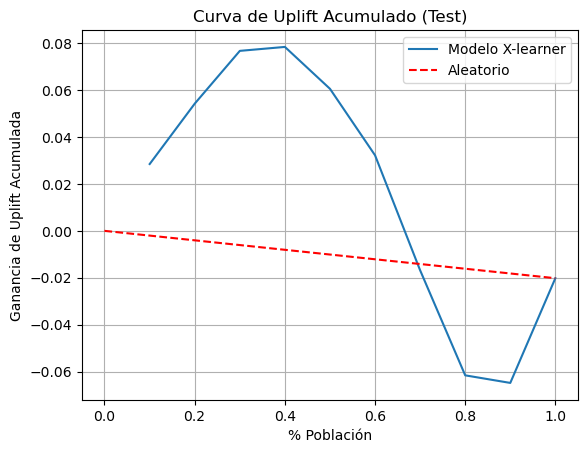

In [38]:
stats, auuc = uplift_curve_auuc(uplift_score, y_test, t_test, n_bins=10)

import matplotlib.pyplot as plt

plt.plot(stats['cum_pop'], stats['cum_uplift'], label='Modelo X-learner')
plt.plot([0, 1], [0, stats['cum_uplift'].iloc[-1]], linestyle='--', color='red', label='Aleatorio')
plt.title('Curva de Uplift Acumulado (Test)')
plt.xlabel('% Población')
plt.ylabel('Ganancia de Uplift Acumulada')
plt.legend()
plt.grid()
plt.show()

C:\Users\gabriel.santamaria\AppData\Local\Temp\ipykernel_26124\2624695080.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auqc = np.trapz(y_model - y_rand, x)


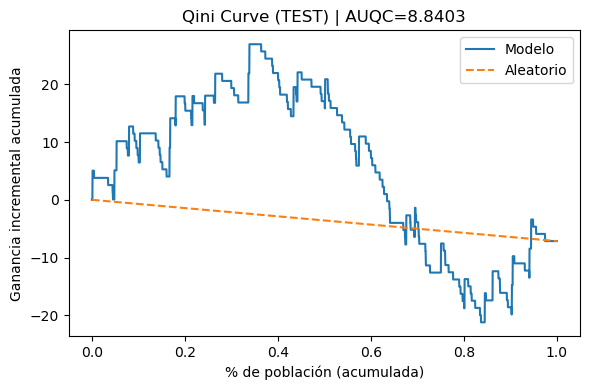

AUQC (test): 8.8403


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Qini curve (TEST)
def qini_curve_plot(uplift_score, y, t, title='Qini Curve (TEST)'):
    """
    uplift_score: array-like con τ̂(x)
    y: labels binarios en TEST (0/1)
    t: indicador de tratamiento en TEST (0/1)
    """
    dfu = pd.DataFrame({'u': uplift_score, 'y': y.values, 't': t.values})
    dfu = dfu.sort_values('u', ascending=False).reset_index(drop=True)

    # Propensión global (para normalizar)
    p = dfu['t'].mean()
    p = np.clip(p, 1e-3, 1-1e-3)

    # Incremental gain por observación (definición estándar)
    inc = dfu['y'] * (dfu['t']/p) - dfu['y'] * ((1-dfu['t'])/(1-p))
    dfu['cum_gain'] = inc.cumsum()

    # Baseline aleatorio: línea entre (0,0) y (1, total_gain)
    x = np.arange(1, len(dfu)+1) / len(dfu)
    y_model = dfu['cum_gain'].values
    y_rand = np.linspace(0, y_model[-1], len(dfu))

    auqc = np.trapz(y_model - y_rand, x)


    plt.figure(figsize=(6,4))
    plt.plot(x, y_model, label='Modelo')
    plt.plot(x, y_rand, linestyle='--', label='Aleatorio')
    plt.xlabel('% de población (acumulada)')
    plt.ylabel('Ganancia incremental acumulada')
    plt.title(f'{title} | AUQC={auqc:.4f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return dfu[['u','y','t','cum_gain']], auqc


qini_df, auqc = qini_curve_plot(uplift_score, y_test, t_test)
print(f"AUQC (test): {auqc:.4f}")


In [40]:
df_resultados = pd.DataFrame({
    'uplift_score': uplift_score,
    'fue_tratado': t_test,
    'realmente_convirtio': y_test
}, index=X_test.index)

df_final = df_fs.join(df_resultados, how='inner')

df_final_ordenado = df_final.sort_values(by='uplift_score', ascending=False)

df_final_ordenado

,rpp_user_id,treat,new_credit_line,gender,antiguedad_meses,wa_enviados_30,wa_leidos_30,wa_respuestas_30,wa_enviados_7,wa_leidos_7,...,fs_isna_num_compras_30d,fs_isna_num_compras_90d,fs_isna_num_ingresos_rc_7_days,fs_isna_num_ingresos_rc_30_days,fs_isna_num_ingresos_rc_90_days,fs_isna_new_credit_line,fs_isna_current_amount,uplift_score,fue_tratado,realmente_convirtio
3585,3c30cf1a-7e11-4eb1-90c6-bfaf09715a4f,0,50000,H,4,10,9,1,1,3,...,0,0,0,0,0,0,0,0.173903,0,0
4348,cae28e4f-63ba-4b63-b853-85eb35320d07,0,5000,M,20,8,11,3,4,3,...,0,0,0,0,0,0,0,0.145956,0,0
13694,736b92c0-262c-4db9-b7da-42e464d9a706,0,50000,H,1,6,4,1,1,1,...,0,0,0,0,0,0,0,0.144257,0,0
526,d5cfcbbd-ee38-4961-9454-65dae942fc2e,0,50000,H,30,10,11,2,1,4,...,0,0,0,0,0,0,0,0.130592,0,0
8005,ee93a868-cd05-4fab-baa9-d0186c8cef22,1,80000,H,29,12,5,1,1,1,...,0,0,0,0,0,0,0,0.128662,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12007,6c2d2d61-31b9-46b8-898c-0ae0275be347,0,25000,M,56,11,6,1,3,1,...,0,0,0,0,0,0,0,-0.163669,0,0
6740,22cad6c0-4333-4d3b-8ccd-35f0d87a1b59,0,10000,H,9,6,1,2,0,1,...,0,0,0,0,0,0,0,-0.163729,0,0
12565,7ad1dd7f-808e-48d3-b308-516a3724af3c,0,25000,M,36,9,1,4,2,0,...,0,0,0,0,0,0,0,-0.168586,0,0
9987,47d8069a-bfb6-4a67-9df3-b827ff83aaf7,0,5000,H,26,14,7,0,1,0,...,0,0,0,0,0,0,0,-0.176439,0,0


In [41]:
# 1) Bins por uplift_score
df_final_ordenado = df_final_ordenado.copy()
df_final_ordenado.loc[:, 'uplift_range'] = pd.qcut(
    df_final_ordenado['uplift_score'],
    q=10,
    duplicates='drop',
    precision=4
)

# 2) Agregación por rango y brazo
analysis_by_range = df_final_ordenado.groupby(['uplift_range', 'fue_tratado']).agg(
    total_conversiones=('realmente_convirtio', 'sum'),
    total_usuarios=('realmente_convirtio', 'count')
).reset_index()

# 3) Tasas de conversión por brazo
analysis_by_range['tasa_conversion'] = (
    analysis_by_range['total_conversiones'] / analysis_by_range['total_usuarios']
)

# 4) Tabla de tasas por rango
final_table_with_ranges = analysis_by_range.pivot_table(
    index='uplift_range',
    columns='fue_tratado',
    values='tasa_conversion'
).rename(columns={0: 'tasa_conv_control', 1: 'tasa_conv_tratados'}).fillna(0.0)

# 5) Lift
final_table_with_ranges['lift_real'] = (
    final_table_with_ranges['tasa_conv_tratados'] - final_table_with_ranges['tasa_conv_control']
)

# 6) Conteos por brazo y total de usuarios por rango
counts = analysis_by_range.pivot_table(
    index='uplift_range',
    columns='fue_tratado',
    values='total_usuarios',
    aggfunc='sum'
).rename(columns={0: 'n_control', 1: 'n_tratado'}).fillna(0).astype(int)

final = final_table_with_ranges.join(counts)
final['n_total'] = final['n_control'] + final['n_tratado']

# 7) Orden descendente por rango (qcut index ordena asc por defecto)
final = final.sort_index(ascending=False)

# 8) Mostrar con formato
display(
    final.style.format({
        'tasa_conv_control': '{:.2%}',
        'tasa_conv_tratados': '{:.2%}',
        'lift_real': '{:.2%}',
        'n_control': '{:,}',
        'n_tratado': '{:,}',
        'n_total': '{:,}'
    })
)


C:\Users\gabriel.santamaria\AppData\Local\Temp\ipykernel_26124\2754083989.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_by_range = df_final_ordenado.groupby(['uplift_range', 'fue_tratado']).agg(
C:\Users\gabriel.santamaria\AppData\Local\Temp\ipykernel_26124\2754083989.py:22: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  final_table_with_ranges = analysis_by_range.pivot_table(
C:\Users\gabriel.santamaria\AppData\Local\Temp\ipykernel_26124\2754083989.py:34: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this 

fue_tratado,tasa_conv_control,tasa_conv_tratados,lift_real,n_control,n_tratado,n_total
uplift_range,,,,,,
"(-0.0242, 0.1739]",4.44%,7.27%,2.83%,225,55,280
"(-0.04545, -0.0242]",4.07%,6.78%,2.71%,221,59,280
"(-0.05911, -0.04545]",4.27%,6.38%,2.11%,234,47,281
"(-0.06883, -0.05911]",2.83%,2.99%,0.15%,212,67,279
"(-0.07808, -0.06883]",5.36%,3.57%,-1.79%,224,56,280
"(-0.08695, -0.07808]",6.61%,3.77%,-2.83%,227,53,280
"(-0.09547, -0.08695]",8.18%,3.33%,-4.85%,220,60,280
"(-0.1064, -0.09547]",6.52%,2.00%,-4.52%,230,50,280
"(-0.1203, -0.1064]",5.78%,5.45%,-0.32%,225,55,280


In [42]:
import joblib, json, time, os
from pathlib import Path

ARTIFACT_DIR = Path("artefacts/uplift_xlearner_v1")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Guarda los tres componentes
joblib.dump(tau1, ARTIFACT_DIR / "tau1.joblib")
joblib.dump(tau0, ARTIFACT_DIR / "tau0.joblib")
joblib.dump(prop_pipeline, ARTIFACT_DIR / "prop_pipeline.joblib")

# 2) (Opcional pero MUY recomendable) guarda metadatos
metadata = {
    "version": "v1",
    "trained_at": time.strftime("%Y-%m-%d"),
    "framework": "sklearn+xgboost",
    "treatment_col": "treat",
    "features": [c for c in X_train.columns if c != "treat"],
    "params": {
        "xgb": {"n_estimators": 300, "learning_rate": 0.01, "max_depth": 4, "reg_alpha": 0.5,
                "subsample": 0.9, "colsample_bytree": 0.9, "random_state": 42},
        "propensity": "Pipeline(StandardScaler -> LogisticRegression(max_iter=1000))"
    }
}
with open(ARTIFACT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)


In [43]:
import joblib, json
import pandas as pd

# 1) Cargar artefactos existentes
tau1 = joblib.load("artefacts/uplift_xlearner_v1/tau1.joblib")
tau0 = joblib.load("artefacts/uplift_xlearner_v1/tau0.joblib")
prop = joblib.load("artefacts/uplift_xlearner_v1/prop_pipeline.joblib")

# (Opcional) leer features desde metadata.json, o defínelos tú
try:
    meta = json.load(open("metadata.json"))
    FEATURES = meta.get("features")
except:
    FEATURES = None  # si no tienes metadata, define la lista a mano

class XLearnerUplift:
    def __init__(self, tau1, tau0, prop, feature_cols=None, treat_col="treat"):
        self.tau1 = tau1
        self.tau0 = tau0
        self.prop = prop
        self.feature_cols = feature_cols
        self.treat_col = treat_col

    def _prep(self, X: pd.DataFrame):
        if self.treat_col in X.columns:
            X = X.drop(columns=[self.treat_col])
        if self.feature_cols is not None:
            # asegura orden/subset de columnas esperado
            X = X[self.feature_cols]
        return X

    def predict_uplift(self, X: pd.DataFrame):
        Xf = self._prep(X.copy())
        e  = self.prop.predict_proba(Xf)[:, 1]
        t1 = self.tau1.predict(Xf)
        t0 = self.tau0.predict(Xf)
        return e * t0 + (1 - e) * t1

# Si no tienes FEATURES en metadata, reemplaza por la lista real de columnas
uplift_pipe = XLearnerUplift(tau1, tau0, prop, feature_cols=FEATURES)

joblib.dump(uplift_pipe, "uplift_xlearner_version_synthetic.joblib")


['uplift_xlearner_version_synthetic.joblib']